In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Schedules

An optimizer, in the framing of that section, is three
decisions: a descent direction, a step size over time, and a way of living
with gradient noise. The preceding sections spent most of their effort on the
direction. This section is about the step size over time, which in practice
is delegated to a *schedule*: a function that maps training time $t$ to the
learning rate $\eta_t$ used at time $t$. The schedule costs nothing to change
and touches no other part of the training loop, and few choices in this
chapter move final accuracy more.

Two facts, both already on the table, force the schedule to exist. First,
with a constant learning rate SGD does not converge: it reaches a *noise
floor* proportional to $\eta$ and rattles there indefinitely
(that section). To finish well, the learning rate must come down.
Second, the rate we ultimately want to train at is often not survivable at
initialization: the first steps at the target rate can destroy the model
before learning begins, so the learning rate must first come *up*. Between
those two constraints — start below the target, end near zero — lies a family
of shapes.

Theory ranks few of these shapes. The results that do exist (the noise-floor
computation, the Robbins–Monro conditions, the minimax optimality of a
well-chosen *constant* rate for a fixed budget) are collected in
that section, and none of them separates cosine
decay from linear decay on a deep network. So this section proceeds the way
the field does: empirically. We fix one small network and one dataset, then
train the same model under one schedule after another: the classical decay
shapes, then warmup, then the warmup–stable–decay schedule that large-model
training adopted in the 2020s. We end with what is settled and what is not.

## A Testbed

We need a problem cheap enough to train dozens of times and honest enough to
show schedule effects. A LeNet-style convolutional network on Fashion-MNIST
(that section) fits: a few seconds per epoch, yet real minibatch
noise, real overfitting, and a real stability ceiling. We apply the small
standard modernizations — ReLU activations, max-pooling, and batch
normalization (that section) after every hidden layer — and we
pin the initialization to Xavier (that section) in both
frameworks. Neither choice is
cosmetic. Without normalization this network's survivable learning-rate
range is narrow and seed-dependent: near its edge, identical settings live
or die by initialization and data-order luck, and every comparison below
would be a coin flip. And PyTorch and Flax draw different default
initializations, so with defaults left in place the two framework tabs
would disagree exactly where this section looks.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import math
import numpy as np
import optax

The training function takes the scheduler as an argument. At the start of
every epoch it asks the scheduler for that epoch's learning rate and installs
it in the optimizer; everything else is the standard classification loop.

The learning rate enters the jitted training step as an array argument, so
changing it every epoch triggers no recompilation; the optimizer itself is
constructed once with a unit rate and the update is pre-scaled. Optax ships
the schedules of this section (and many more) in `optax.schedules`; we write
ours as plain callables to keep the mechanics visible.

In [2]:
xavier = nnx.initializers.xavier_uniform()

class Net(nnx.Module):
    def __init__(self, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.conv1 = nnx.Conv(1, 6, kernel_size=(5, 5), padding='same',
                              kernel_init=xavier, rngs=rngs)
        self.bn1 = nnx.BatchNorm(6, rngs=rngs)
        self.conv2 = nnx.Conv(6, 16, kernel_size=(5, 5), padding='valid',
                              kernel_init=xavier, rngs=rngs)
        self.bn2 = nnx.BatchNorm(16, rngs=rngs)
        self.fc1 = nnx.Linear(16 * 5 * 5, 120, kernel_init=xavier, rngs=rngs)
        self.bn3 = nnx.BatchNorm(120, rngs=rngs)
        self.fc2 = nnx.Linear(120, 84, kernel_init=xavier, rngs=rngs)
        self.bn4 = nnx.BatchNorm(84, rngs=rngs)
        self.fc3 = nnx.Linear(84, 10, kernel_init=xavier, rngs=rngs)

    def __call__(self, x):
        x = nnx.max_pool(nnx.relu(self.bn1(self.conv1(x))),
                         window_shape=(2, 2), strides=(2, 2))
        x = nnx.max_pool(nnx.relu(self.bn2(self.conv2(x))),
                         window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = nnx.relu(self.bn3(self.fc1(x)))
        x = nnx.relu(self.bn4(self.fc2(x)))
        return self.fc3(x)

def net_fn():
    return Net()

loss_fn = optax.softmax_cross_entropy_with_integer_labels

batch_size = 256
data = d2l.FashionMNIST(batch_size=batch_size)
train_iter = data.get_dataloader(train=True)
test_iter = data.get_dataloader(train=False)

def evaluate_accuracy_jax(model, data_iter):
    @nnx.jit
    def eval_step(model, X, y):
        y_hat = model(X)
        return jnp.array([jnp.sum(jnp.argmax(y_hat, axis=1) == y),
                          y.shape[0]])

    model.eval()  # use running averages in the BatchNorm layers
    metric = jnp.zeros(2)  # num_correct, num_examples
    for X, y in data_iter:
        X, y = jnp.array(X), jnp.array(y)
        metric += eval_step(model, X, y)
    return float(metric[0] / metric[1])

def train(net, train_iter, test_iter, num_epochs, lr, scheduler=None,
          animator=None, epoch_offset=0):
    model = net if isinstance(net, nnx.Module) else net()
    # One optimizer for the entire run. The scalar learning rate is an array
    # argument to the compiled step, so changing it does not recompile.
    optimizer = nnx.Optimizer(model, optax.sgd(1.0), wrt=nnx.Param)

    @nnx.jit
    def train_step(model, optimizer, X, y, learning_rate):
        def compute_loss(model):
            logits = model(X)
            loss = jnp.mean(loss_fn(logits, y))
            correct = jnp.sum(jnp.argmax(logits, axis=1) == y)
            return loss, correct
        (l, correct), grads = nnx.value_and_grad(
            compute_loss, has_aux=True)(model)
        grads = jax.tree.map(lambda g: learning_rate * g, grads)
        optimizer.update(model, grads)
        return jnp.array([l * X.shape[0], correct, X.shape[0]])

    if animator is None:
        animator = d2l.Animator(xlabel='epoch', xlim=[0, num_epochs],
                                legend=['train loss', 'train acc',
                                        'test acc'])
    num_batches = len(train_iter)
    for epoch in range(num_epochs):
        model.train()
        metric = jnp.zeros(3)  # train_loss, train_correct, num_examples
        learning_rate = jnp.asarray(scheduler(epoch) if scheduler else lr)
        for i, (X, y) in enumerate(train_iter):
            X, y = jnp.array(X), jnp.array(y)
            metric += train_step(model, optimizer, X, y, learning_rate)
            if (i + 1) % 50 == 0:
                train_loss, train_acc = np.asarray(
                    metric[:2] / metric[2]).tolist()
                animator.add(epoch_offset + epoch + i / num_batches,
                             (train_loss, train_acc, None))
        train_loss, train_acc = np.asarray(metric[:2] / metric[2]).tolist()
        test_acc = evaluate_accuracy_jax(model, test_iter)
        animator.add(epoch_offset + epoch + 1, (None, None, test_acc))
    print(f'train loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')

The baseline is the schedule most code starts life with: a constant. We pick
$\eta = 0.3$ and train for 30 epochs.

train loss 0.060, train acc 0.978, test acc 0.901


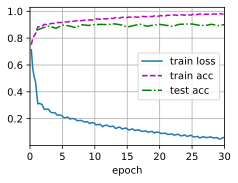

In [3]:
lr, num_epochs = 0.3, 30
train(net_fn, train_iter, test_iter, num_epochs, lr)

Two things go wrong, and they are the two failure modes the rest of the
section addresses. The training loss stays visibly noisy to the end: the
iterate is riding its noise floor, and no amount of extra training lowers it.
And while training accuracy keeps climbing, test accuracy stalls after
roughly ten epochs; the widening gap is overfitting. Both symptoms respond
to a decaying learning rate — though, as the first attempt below shows, not
to every decaying rate.

## Decay Schedules

A scheduler here is any callable that maps the epoch index to a learning
rate. Statelessness is worth insisting on: a schedule should be a *function
of time*, not an object that remembers how often it was called, because a
pure function can be plotted, resumed at epoch 17, or evaluated backwards
without bookkeeping. That discipline looks pedantic now and pays off at the
end of this section, when we branch new schedules off the middle of a
finished run.

### Square-Root Decay

that section established the convex baseline: with
$\eta_t = \eta_0\, (t+1)^{-1/2}$, SGD converges at the optimal rate for
convex problems. That makes square-root decay the theory-first choice.

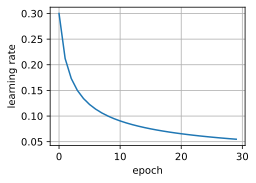

In [4]:
class SquareRootScheduler:
    def __init__(self, lr=0.1):
        self.lr = lr

    def __call__(self, epoch):
        return self.lr * pow(epoch + 1.0, -0.5)

scheduler = SquareRootScheduler(lr=0.3)
d2l.plot(d2l.arange(num_epochs), [scheduler(t) for t in range(num_epochs)],
         xlabel='epoch', ylabel='learning rate')

Training with it is a one-argument change.

train loss 0.090, train acc 0.970, test acc 0.895


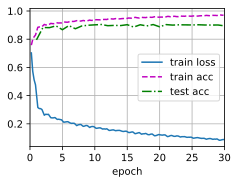

In [5]:
train(net_fn, train_iter, test_iter, num_epochs, lr, scheduler)

The loss curve is smoother and the late-epoch noise reduced, the noise
floor shrinking as $\eta_t$ falls. But the final test accuracy is no better
than the constant baseline's, in either framework. The diagnosis is the
*shape*: square-root decay manages to be
timid at both ends. It halves the rate within the first three epochs,
giving up the large early steps that do the exploring, yet it ends the run
at $\eta_{29} \approx 0.05$, the largest final rate of any decay in this
section, so it never fully quenches the noise either. Its guarantee speaks
about convex problems; a neural network wants the opposite temperament.
Every schedule that follows has it: stay high longer, decay harder at the
end.

### Multiplicative Decay

An alternative with the same monotone spirit is multiplicative (exponential)
decay, $\eta_{t+1} = \eta_t \cdot \alpha$ for some $\alpha \in (0, 1)$,
usually clipped at a floor so the rate does not vanish entirely:
$\eta_t = \max(\eta_{\min},\ \eta_0 \cdot \alpha^t)$.

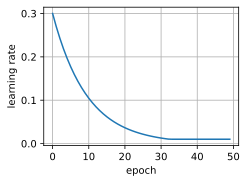

In [6]:
class FactorScheduler:
    def __init__(self, factor=1, stop_factor_lr=1e-7, base_lr=0.1):
        self.factor = factor
        self.stop_factor_lr = stop_factor_lr
        self.base_lr = base_lr

    def __call__(self, epoch):
        return max(self.stop_factor_lr, self.base_lr * self.factor ** epoch)

scheduler = FactorScheduler(factor=0.9, stop_factor_lr=0.01, base_lr=0.3)
d2l.plot(d2l.arange(50), [scheduler(t) for t in range(50)],
         xlabel='epoch', ylabel='learning rate')

The shape differs from square root where it counts: with $\alpha = 0.9$ the
early decline is gentler, and by epoch 30 the rate has fallen more than
twentyfold where square root managed fivefold — a hard quench at the end
instead of a lingering one. The floor guards the other edge: with $\alpha$
too small the rate collapses before the model has learned anything.

train loss 0.079, train acc 0.976, test acc 0.909


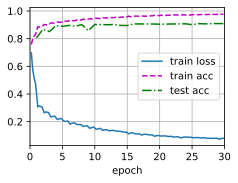

In [7]:
train(net_fn, train_iter, test_iter, num_epochs, lr, scheduler)

This time both symptoms respond: the run ends quiet, the test accuracy sits
visibly above the constant baseline's, and the train–test gap narrows. The
remaining shapes repeat this pattern; what varies is how the high-rate
budget is spent and how the descent is timed.

### Piecewise Constant Decay

The workhorse of the ImageNet era holds the rate constant and cuts it by a
fixed factor at preset epochs. The intuition matches the noise-floor picture
of that section step for step: ride the current floor until progress
stalls, then lower the floor and ride again. Training curves under this
schedule have a characteristic staircase shape, with a visible drop in loss
right after each cut.

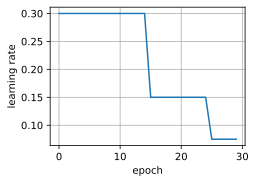

In [8]:
class MultiFactorScheduler:
    def __init__(self, milestones, factor, base_lr):
        self.milestones = milestones
        self.factor = factor
        self.base_lr = base_lr

    def __call__(self, epoch):
        lr = self.base_lr
        for milestone in self.milestones:
            if epoch >= milestone:
                lr *= self.factor
        return lr

scheduler = MultiFactorScheduler(milestones=[15, 25], factor=0.5, base_lr=0.3)
d2l.plot(d2l.arange(num_epochs), [scheduler(t) for t in range(num_epochs)],
         xlabel='epoch', ylabel='learning rate')

train loss 0.035, train acc 0.990, test acc 0.903


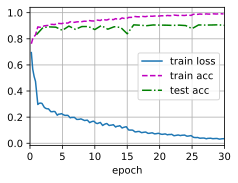

In [9]:
train(net_fn, train_iter, test_iter, num_epochs, lr, scheduler)

The catch is the milestones themselves: someone has to pick them, and the
right answer depends on the budget, the dataset, and the architecture. The
next shape removes that knob.

### Cosine Decay

You have trained with this schedule already: the recipe of
that section combined cosine decay with warmup as standard
equipment, and the models of that chapter rode it to their best accuracies.
What that section took on faith, this one examines.
@Loshchilov.Hutter.2016 proposed the shape on the reasoning that one
should not decrease the learning rate too drastically at the start and
should end with a very small rate to refine the solution. For a horizon of
$T$ epochs,

$$\eta_t = \eta_T + \frac{\eta_0 - \eta_T}{2}\left(1 + \cos(\pi t/T)\right),$$

which glides from $\eta_0$ to $\eta_T$ with no kinks and only the peak rate
left to tune. For $t > T$ the rate is pinned at $\eta_T$. The implementation
below also carries an optional linear ramp over the first `warmup_steps`
epochs; we ignore it for the moment and pick it up in the next subsection.

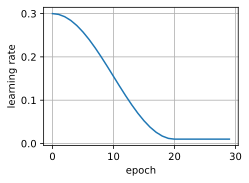

In [10]:
class CosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0,
                 warmup_steps=0, warmup_begin_lr=0):
        self.max_update = max_update
        self.base_lr = base_lr
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            increase = (self.base_lr - self.warmup_begin_lr) \
                       * (epoch + 1) / self.warmup_steps
            return self.warmup_begin_lr + increase
        if epoch < self.max_update:
            t = (epoch - self.warmup_steps) \
                / (self.max_update - self.warmup_steps)
            return self.final_lr + (self.base_lr - self.final_lr) \
                * (1 + math.cos(math.pi * t)) / 2
        return self.final_lr

scheduler = CosineScheduler(max_update=20, base_lr=0.3, final_lr=0.01)
d2l.plot(d2l.arange(num_epochs), [scheduler(t) for t in range(num_epochs)],
         xlabel='epoch', ylabel='learning rate')

train loss 0.080, train acc 0.975, test acc 0.910


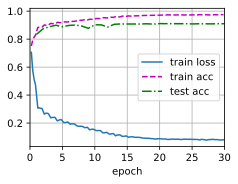

In [11]:
train(net_fn, train_iter, test_iter, num_epochs, lr, scheduler)

On this testbed cosine decay lands in the same accuracy range as
multiplicative and piecewise constant decay — among the stay-high,
decay-hard shapes the differences are too close to call from a single run,
and claiming otherwise would be reading tea leaves. Cosine's appeal is
operational: one parameter, no milestones, graceful behavior across
budgets. That, more than
any measured superiority, is why it spread.

## Warmup

Every schedule so far answers "how should the rate come down?". Warmup
answers a different question: how should it come up?
that section gave the operational answer — a freshly
initialized network produces large, badly scaled gradients, so ramp gently —
and you have been warming up ever since. The mechanism deserves a closer
look. At initialization the parameters are random and the loss surface
around them can be sharply curved in some directions. A learning rate that
the network would happily accept after a few epochs of training can be fatal
in step one: the updates overshoot, and the run never recovers.
@Goyal.Dollar.Girshick.ea.2017 ran into exactly this when scaling
ImageNet training to large batches and correspondingly large learning rates,
and made the fix standard practice: ramp the rate linearly from near zero to
the target over the first few epochs. Why this works has since been studied
directly: early training at a growing rate progressively *reduces the
sharpness* of the loss around the iterate, so the network can tolerate a
target rate that would have diverged from cold
[@Kalra.Barkeshli.2024]. Warmup does not make every rate safe — a
stability ceiling remains — but it moves the ceiling up, and it lets
training start fast without betting the run on the first step. For adaptive
methods such as Adam there is a second, independent reason to warm up: the
preconditioner is estimated from a handful of gradients early on and should
not be trusted at full step size (that section).
Our testbed uses plain SGD, which isolates the curvature story.

Here is the failure. Our network, thanks to its batch normalization layers,
shrugs off surprisingly large learning rates from a cold start — but not
without limit. We train at $\eta = 7.5$, twenty-five times the rate of our
baseline:

train loss 2.011, train acc 0.196, test acc 0.198


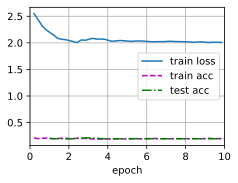

In [12]:
hot_lr = 7.5
train(net_fn, train_iter, test_iter, 10, hot_lr)

The run collapses in the first epoch and stays collapsed: the loss hovers
near $\ln 10 \approx 2.3$, the loss of predicting all ten classes uniformly,
and accuracy never leaves the vicinity of chance. The oversized first steps
threw the parameters so far from the initialization that no useful signal
survived. Now the same target rate, reached through a five-epoch linear
ramp:

In [13]:
def warmup(epoch):
    return hot_lr * min((epoch + 1) / 5, 1)

train loss 0.204, train acc 0.923, test acc 0.879


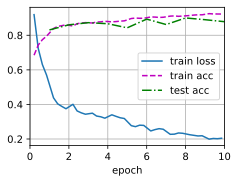

In [14]:
train(net_fn, train_iter, test_iter, 10, hot_lr, warmup)

With the ramp, the identical network trains at the identical target rate to
80–90% accuracy in ten epochs. The contrast is reproducible across
restarts, but it is a band, not a magic trick: cold starts at somewhat lower
rates survive, and at rates far enough above the ceiling no warmup length
saves the run. Warmup widens the window of usable peak rates; it does not
remove the window's edge. @Gotmare.Keskar.Xiong.ea.2018 probed what warmup does
inside deeper networks and found its main measurable effect is exactly this
kind of containment: it limits how far the parameters, especially in later
layers, can diverge while everything is still random.

Combining the ramp with cosine decay gives the schedule that trained most of
the deep learning models of the late 2010s and remains a strong default:
linear warmup to the peak, cosine decay to near zero.

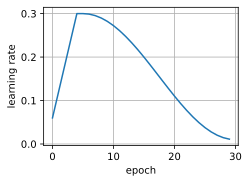

In [15]:
scheduler = CosineScheduler(max_update=30, base_lr=0.3, final_lr=0.01,
                            warmup_steps=5)
d2l.plot(d2l.arange(num_epochs), [scheduler(t) for t in range(num_epochs)],
         xlabel='epoch', ylabel='learning rate')

train loss 0.046, train acc 0.988, test acc 0.910


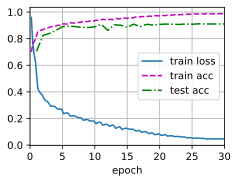

In [16]:
train(net_fn, train_iter, test_iter, num_epochs, lr, scheduler)

## Warmup–Stable–Decay

Cosine decay has a defect that none of our plots show: the horizon $T$ is
baked into the schedule from step one. Every intermediate checkpoint of a
cosine run is a model whose learning rate was mid-descent: fine to resume,
useless as a finished product, because its rate never came down. Decide after
the fact that the model should have trained for twice as long and the
schedule has nothing left to give; the honest options are to retrain from
scratch or to splice schedules in ways cosine was never designed for. For a
single fixed-budget run this is no burden. It becomes one when the budget is
genuinely unknown — data keeps arriving, or the loss is still falling at $T$
— and it is acute when one training run is supposed to yield *models at
several budgets*, as in a scaling-law study (that section).

The schedule that large language model training converged on instead is
**warmup–stable–decay** (WSD) [@Hu.Tu.Han.ea.2024]: warm up, hold the
peak rate *constant* for most of the run, and decay only in a short final
phase, typically the last 10–20% of the budget. The MiniCPM team popularized
it, and @Hagele.Bakouch.Kosson.ea.2024 showed that it matches cosine
across budgets. The constant plateau is what buys the flexibility: every
plateau checkpoint is a live, horizon-free starting point, and the decay
becomes a *harvest step* you can run whenever — and as often as — you want a
finished model.

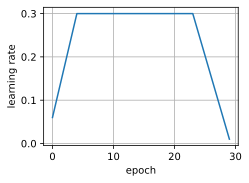

In [17]:
class WSDScheduler:
    def __init__(self, max_update, decay_steps, base_lr=0.1, final_lr=0,
                 warmup_steps=0):
        self.max_update = max_update
        self.decay_steps = decay_steps
        self.base_lr = base_lr
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.base_lr * (epoch + 1) / self.warmup_steps
        if epoch < self.max_update - self.decay_steps:
            return self.base_lr
        t = min((epoch - (self.max_update - self.decay_steps) + 1)
                / self.decay_steps, 1)
        return self.base_lr + (self.final_lr - self.base_lr) * t

scheduler = WSDScheduler(max_update=30, decay_steps=6, base_lr=0.3,
                         final_lr=0.01, warmup_steps=5)
d2l.plot(d2l.arange(num_epochs), [scheduler(t) for t in range(num_epochs)],
         xlabel='epoch', ylabel='learning rate')

Trained at the same peak rate and the same 30-epoch budget as the
warmup-plus-cosine run above, WSD lands in the same final accuracy range.
Watch the *shape* of its loss curve rather than the endpoint: through the
long plateau the training loss sits above the cosine run's at the same
epoch, then drops abruptly once the decay begins.

train loss 0.027, train acc 0.994, test acc 0.909


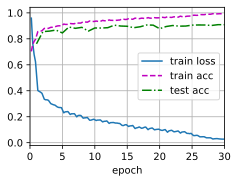

In [18]:
train(net_fn, train_iter, test_iter, num_epochs, lr, scheduler)

That final cliff is the signature of every published WSD loss curve, and
@Wen.Li.Wang.ea.2024 give it a useful geometry. Picture the loss
surface as a *river valley*: steep walls transverse to a floor that winds
downhill at a gentle slope. At the plateau's high learning rate the iterate
bounces between the walls while drifting fast along the floor. The bouncing
inflates the measured loss — the iterate is always partway up a wall — but
the drift is real progress, covering distance along the valley that small
steps could not match. The decay quenches the bouncing: the iterate settles
to the floor it has already reached, and the loss falls in a cliff. On this
picture the plateau does the traveling and the decay does the landing, which
is why the plateau can be extended for as long as you keep training and why
a short decay suffices. It is the noise-ball argument of that section
upgraded from a bowl to a winding valley. the figure
draws it: the same
seeded noise drives both runs, and the only difference between bouncing
forever and landing on the floor is what the learning rate does at the end.

![The river-valley picture of warmup–stable–decay. Stochastic gradient descent on a winding valley with steep walls: after a brief warmup, the constant high learning rate bounces off the walls yet keeps moving downstream, while the branch whose learning rate decays settles onto the valley floor it had already reached.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-opt-river-valley.svg)

### Branching Off the Plateau

The river-valley picture makes a concrete operational prediction: since a
plateau checkpoint's only deficit is the bouncing, a decay branched off *any*
plateau point should land it. We verify the whole WSD workflow, drawing all
three runs below on one shared pair of axes over absolute epochs 0–36 so
that the branch point stays visible. First train
warmup-plus-stable only; this is the run an open-ended training job would
be in the middle of. Its training loss hovers noisily at several times the
level the decayed runs reach, and its test accuracy wanders at or below
theirs: not yet a finished model.

train loss 0.086, train acc 0.968, test acc 0.896


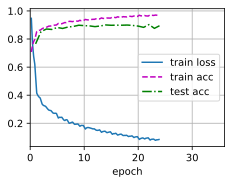

In [19]:
model_plateau = net_fn()
stable = WSDScheduler(max_update=24, decay_steps=0, base_lr=0.3,
                      warmup_steps=5)
board = d2l.Animator(xlabel='epoch', xlim=[0, 36],
                     legend=['train loss', 'train acc', 'test acc'])
train(model_plateau, train_iter, test_iter, 24, lr, stable, animator=board)

Nothing about this run committed to a horizon, so keep it going: six more
epochs at the constant peak rate, as if the budget had just been extended.

train loss 0.063, train acc 0.978, test acc 0.899


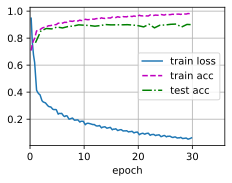

In [20]:
train(model_plateau, train_iter, test_iter, 6, lr, animator=board,
      epoch_offset=24)
board.fig

Now harvest. We clone the live run — it could continue tomorrow — and branch
a six-epoch decay off the clone, assembling a 36-epoch WSD schedule that
nobody planned when training started:

train loss 0.015, train acc 0.998, test acc 0.911


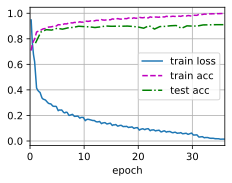

In [21]:
model_branch = nnx.clone(model_plateau)
decay = WSDScheduler(max_update=6, decay_steps=6, base_lr=0.3, final_lr=0.01)
train(model_branch, train_iter, test_iter, 6, lr, decay, animator=board,
      epoch_offset=30)
board.fig

The loss cliff lands at epoch 30, exactly where the decay branched off the
plateau, and the branched model reaches the same accuracy range as the full
cosine and WSD runs — without the horizon having been chosen in advance.
This is the property that spread WSD at the frontier: one long stable run
plus
cheap branched decays yields models at many budgets for roughly the price of
one, where cosine would demand a separate full run per budget
[@Hagele.Bakouch.Kosson.ea.2024]. One practical note: our optimizer is
plain SGD, which carries no state, so cloning the parameters was enough.
With momentum or Adam, the optimizer state must be checkpointed and branched
along with them.

### The Current Frontier

Three developments close the section.

**Linear decay to zero.** @Defazio.Cutkosky.Mehta.ea.2023 argue from
worst-case analysis that a linear decay to exactly zero is the shape to
beat, and @Bergsma.Dey.Gosal.ea.2025 back this at LLM scale:
across model sizes and budgets, warmup plus linear-to-zero matched or beat
both cosine and WSD variants in their sweeps. The final rate matters more
than the path taken to it; schedules that stop at a nonzero floor leave the
last increment of loss on the table.

**Schedule-free methods.** @Defazio.Yang.Mehta.ea.2024 remove the
schedule altogether: keep stepping at a constant rate, and *evaluate* a
running average of the iterates rather than the latest one. The scheme is
coupled rather than post-hoc: each gradient is taken at an interpolation
between the fast iterate and the average, and the average is what you
evaluate (the exact recurrence is in the exercises). Averaging plays
the same noise-quenching role as decay — the bounces cancel in the mean — so
the averaged iterate behaves like an implicitly decayed run whose horizon is
always "now", the same operational property as WSD's branched decays.
that section returns to weight averaging in its more common role
as a cheap accuracy bump [@Izmailov.Podoprikhin.Garipov.ea.2018]; the
exercises below have you watch the schedule-free effect on a noisy quadratic.

**Cosine is not dead.** The WSD-versus-cosine question is not settled. The
GLM-4.5 team ablated both at scale and shipped cosine [@Zeng.Lv.Zheng.ea.2025],
and at matched tuning the measured differences between modern schedules are
small — consistently smaller than the gains from tuning the peak rate well.
What is settled is operational: plateau checkpoints that can be decayed on
demand are strictly more flexible than a schedule that commits to its
horizon at step one, and that, more than any loss-curve gap, is why WSD and
its relatives became widespread where the training horizon is open-ended.

## Summary

* A schedule is a function from training time to learning rate. Decay exists
  to lower SGD's noise floor (and, empirically, the train–test gap); warmup
  exists because the target rate is often unsafe at initialization.
* The decay shapes disagree more in their timing than their endpoints.
  Square-root decay gives up the high early rate and, on our testbed, lands
  below the constant baseline; multiplicative, piecewise constant, and
  cosine decay stay high longer, quench harder at the end, improve on the
  baseline, and are too close to call from single runs. Cosine won on
  convenience:
  one parameter, no milestones.
* Warmup raises the stability ceiling by giving the network time to reduce
  sharpness before the full rate arrives. At rates where a cold start dies,
  a short linear ramp trains.
* Warmup–stable–decay holds the peak rate for most of the run and decays
  late. Its loss cliff is the noise ball collapsing (the river-valley
  picture), and its plateau checkpoints can be branched into finished models
  at any time — the property behind its adoption in large-scale training.
* Linear decay to zero is a strong, simple recent default; schedule-free
  averaging replaces decay with iterate averaging; WSD versus cosine remains
  genuinely contested.

## Exercises

1. Experiment with the constant baseline: train at
   $\eta \in \{0.03, 0.1, 0.3, 0.5\}$. Which gives the best final test
   accuracy? What happens to the train–test gap as $\eta$ shrinks?
1. Implement polynomial decay $\eta_t = \eta_0 (\beta t + 1)^{-\alpha}$.
   Setting $\alpha = 0.5$ recovers square-root decay; try
   $\alpha \in \{0.25, 1, 2\}$ and describe how $\alpha$ trades early
   progress against late noise.
1. How long should warmup last? At the target rate of this section's demo,
   vary the ramp from 1 to 10 epochs. Then raise the target rate until no
   warmup length saves the run — the stability ceiling is real, warmup only
   moves it.
1. Extend the plateau run of this section to 60 epochs and branch 6-epoch
   decays at epochs 30, 40, and 50. Plot final test accuracy against branch
   point. You have traced an accuracy-versus-budget curve from a single run,
   which is the experimental design of @Hagele.Bakouch.Kosson.ea.2024 .
1. Implement schedule-free SGD [@Defazio.Yang.Mehta.ea.2024] on a noisy
   2-D quadratic $f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^\top
   \mathrm{diag}(1, 10)\, \mathbf{x}$ with Gaussian gradient noise. Iterate
   $\mathbf{y}_t = (1-\beta)\mathbf{z}_t + \beta \mathbf{x}_t$,
   $\mathbf{z}_{t+1} = \mathbf{z}_t - \eta \nabla f(\mathbf{y}_t)$,
   $\mathbf{x}_{t+1} = (1 - c_{t+1})\mathbf{x}_t + c_{t+1}\mathbf{z}_{t+1}$
   with $c_{t+1} = 1/(t+1)$ and $\beta = 0.9$. Plot $f(\mathbf{z}_t)$ and
   $f(\mathbf{x}_t)$ over 500 steps at constant $\eta$. The base iterate
   rides its noise ball; the averaged iterate keeps descending, tracking an
   implicit decay without ever changing $\eta$.
1. Constant-rate SGD does not converge, but its stationary noise is not
   useless: @Welling.Teh.2011 turn it into a sampler. Read about
   stochastic gradient Langevin dynamics and relate the injected noise scale
   to the noise floor of that section.

[Discussions](https://d2l.discourse.group/t/1081)